## Paso 1 · Carga de datos reales (`processed_data`)

Se utiliza la conexión al clúster de **MongoDB Atlas** (colección `processed_data`). A diferencia de versiones anteriores de este notebook, **no existe mecanismo de generación de datos sintéticos**: si la conexión falla, el notebook se detiene explícitamente, porque cualquier indicador estratégico, táctico u operativo construido sobre datos inventados invalidaría las decisiones de negocio que se proponen en este informe.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv
import os
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RECURSOS_DIR = "descripcion_eda_recursos"
os.makedirs(RECURSOS_DIR, exist_ok=True)

print("=" * 80)
print("PASO 1: CONECTAR A MONGODB ATLAS (processed_data) Y CARGAR DATOS REALES")
print("=" * 80)

# Carga de variables de entorno (.env) — se buscan en rutas usuales del contenedor
load_dotenv("/home/jovyan/work/.env")
load_dotenv("../.env")
load_dotenv()

# IMPORTANTE: este notebook trabaja únicamente con datos reales del pipeline.
# Si la conexión a Atlas falla, el notebook se detiene en vez de simular datos,
# ya que cualquier KPI calculado sobre datos inventados invalidaría las
# decisiones estratégicas, tácticas y operativas que se construyen más abajo.
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017/")
DB_NAME = os.getenv("DB_NAME", "db_g9agrotech")
PROCESSED_COLLECTION = os.getenv("PROCESSED_COLLECTION", "processed_data")

try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=15000)
    client.admin.command("ping")
    db = client[DB_NAME]
    processed = db[PROCESSED_COLLECTION]
    df_raw = pd.DataFrame(list(processed.find({})))
    if df_raw.empty:
        raise ValueError("La colección procesada está vacía.")
    print(f"✅ Conectado a MongoDB Atlas ({DB_NAME}.{PROCESSED_COLLECTION})")
    print(f"✅ Registros reales cargados: {len(df_raw):,}")
except Exception as exc:
    raise RuntimeError(
        "No se pudo cargar MongoDB Atlas. Este notebook NO genera datos "
        "sintéticos de respaldo: verifica la variable MONGO_URI en tu archivo "
        f".env, que el clúster esté en estado activo y que el IP Whitelisting "
        f"incluya tu IP actual. Detalle del error original: {exc}"
    )

n_inicial = len(df_raw)
print(f"\nColumnas disponibles en el dataset real: {list(df_raw.columns)}")
print(f"Registros iniciales (raw_data): {n_inicial:,}")


MESES_ES = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre",
}


ANIO_REF_FIJO, MES_REF_FIJO = 2025, 3

def mes_referencia(df=None, productos=None, min_registros=1):
    """Mes de referencia fijo (Marzo 2025) para gráficos tácticos y operativos."""
    return ANIO_REF_FIJO, MES_REF_FIJO, MESES_ES[MES_REF_FIJO]


def preparar_df_analisis(df_raw, n_inicial=None):
    """Limpieza estándar del pipeline (Paso 2). Reutilizable si ejecutas KPIs sueltos."""
    df = df_raw[df_raw["producto"].notna()].drop_duplicates()
    df = df[df["producto"].str.lower() != "petroleo"]

    for col in ["precio_petroleo", "precio_petroleo_contexto", "tasa_cambio"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    for col in ["precio", "temperatura", "humedad", "precipitaciones", "radiacion_uv"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "fecha" not in df.columns:
        raise RuntimeError("processed_data no trae columna 'fecha'.")

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    if df["fecha"].isna().any() and {"año", "dia_año"}.issubset(df.columns):
        mask_sin_fecha = df["fecha"].isna()
        df.loc[mask_sin_fecha, "fecha"] = (
            pd.to_datetime(df.loc[mask_sin_fecha, "año"].astype(int).astype(str) + "-01-01")
            + pd.to_timedelta(df.loc[mask_sin_fecha, "dia_año"].astype(float) - 1, unit="D")
        )
    df["mes_num"] = df["fecha"].dt.month
    df["semana"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["anio"] = df["fecha"].dt.year
    df["mes_nombre"] = df["fecha"].dt.month.map(MESES_ES)

    df = df.dropna(subset=["precio", "producto", "fecha"])
    df["precio_log"] = np.log1p(df["precio"])

    productos_lista = sorted(df["producto"].unique().tolist())
    features_climaticas = [
        c for c in ["temperatura", "humedad", "precipitaciones", "radiacion_uv"] if c in df.columns
    ]
    n_final = len(df)
    if n_inicial is None:
        n_inicial = len(df_raw)
    n_descartados = n_inicial - n_final
    pct_descartados = (n_descartados / n_inicial) * 100 if n_inicial else 0.0

    return df, productos_lista, features_climaticas, n_final, n_descartados, pct_descartados


PASO 1: CONECTAR A MONGODB ATLAS (processed_data) Y CARGAR DATOS REALES
✅ Conectado a MongoDB Atlas (db_g9agrotech.processed_data)
✅ Registros reales cargados: 7,021

Columnas disponibles en el dataset real: ['_id', 'año', 'calidad', 'comuna', 'fecha', 'integrante', 'lugar_monitoreo', 'mes', 'precio', 'producto', 'variedad', 'fertilizante', 'variacion', 'estacion', 'iva', 'maximo', 'minimo', 'p_apertura', 'precio_normalizado', 'mes_num', 'dia_año', 'semana_año', 'estacionalidad_index', 'temperatura', 'humedad', 'precipitaciones', 'radiacion_uv', 'tasa_cambio', 'comuna_index', 'lugar_monitoreo_index', 'variedad_index']
Registros iniciales (raw_data): 7,021


## Paso 2 · Data Wrangling (Filtros Estratégicos de Relevancia)

**Evaluación de pertinencia de atributos:**
* Se eliminan `tasa_cambio` y cualquier residuo de `precio_petroleo`: son variables macroeconómicas ajenas al sector agrícola que aparecieron como ruido en la captura (filas de "petróleo" inyectadas en la columna `producto`) y no aportan valor explicativo al precio de los commodities monitoreados.
* **Se conservan `comuna` y `lugar_monitoreo` (canal de venta)**, a diferencia de versiones anteriores de este análisis: ambas variables son necesarias para los indicadores estratégicos de mezcla de canales y distribución geográfica que exige la rúbrica del Hito 1 (Variedad de etiquetas) y no constituyen ruido, sino dimensiones de negocio reales capturadas por el scraper.
* **Se conserva `fecha`** (fecha de captura real del registro) como única dimensión temporal verídica del dataset. La columna `mes_num` se recalcula directamente desde `fecha` para evitar inconsistencias, en lugar de usarse como variable independiente.


In [2]:
print("=" * 80)
print("PASO 2: DATA WRANGLING & FILTRADO DE VARIABLES IRRELEVANTES")
print("=" * 80)

if "df_raw" not in globals():
    raise RuntimeError("Ejecuta primero el Paso 1 (carga MongoDB) para definir df_raw.")

df, productos_lista, features_climaticas, n_final, n_descartados, pct_descartados = preparar_df_analisis(
    df_raw, n_inicial
)

for col in ["precio_petroleo", "precio_petroleo_contexto", "tasa_cambio"]:
    if col in df_raw.columns:
        print(f"❌ Variable eliminada por falta de pertinencia de negocio: {col}")

print(f"✅ Registros agrícolas puros listos para el análisis: {n_final:,}")
print(f"🧹 Registros descartados en limpieza (KPI Veracidad): {n_descartados:,} ({pct_descartados:.1f}%)")
print(f"📅 Rango de fechas real de captura: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"Productos detectados: {productos_lista}")
print(f"Features climáticas disponibles: {features_climaticas}")


PASO 2: DATA WRANGLING & FILTRADO DE VARIABLES IRRELEVANTES
❌ Variable eliminada por falta de pertinencia de negocio: tasa_cambio
✅ Registros agrícolas puros listos para el análisis: 6,655
🧹 Registros descartados en limpieza (KPI Veracidad): 366 (5.2%)
📅 Rango de fechas real de captura: 2024-01-01 → 2025-12-29
Productos detectados: ['Limón', 'Naranja', 'Palta', 'Papa', 'Tomate', 'Uva']
Features climáticas disponibles: ['temperatura', 'humedad', 'precipitaciones', 'radiacion_uv']


## Paso 3 · Repositorio Único de Datos (Tabla Maestra de KPIs)

Construcción de las métricas agregadas por producto que alimentarán jerárquicamente cada nivel del dashboard: estadísticas descriptivas (PSA), correlación de Spearman entre precio y variables climáticas, y segmentación no supervisada (K-Means + PCA) con selección automática del número óptimo de clústeres mediante el coeficiente de silueta.

Todo se calcula sobre `df`, el DataFrame real filtrado en el Paso 2 — no se generan datos nuevos.


In [3]:
def calcular_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lower) | (serie > upper)).sum()

# Requiere df y productos_lista del Paso 2
if "df" not in globals() or not isinstance(globals().get("df"), pd.DataFrame):
    if "df_raw" not in globals():
        raise RuntimeError("Ejecuta el Paso 1 (MongoDB) y el Paso 2 antes de este bloque.")
    if "preparar_df_analisis" not in globals():
        raise RuntimeError("Ejecuta el Paso 1 completo (define preparar_df_analisis) y luego el Paso 2.")
    df, productos_lista, features_climaticas, _, _, _ = preparar_df_analisis(
        df_raw, globals().get("n_inicial")
    )
    print("ℹ️ df reconstruido desde df_raw (ejecuta Paso 2 para evitar esto).")
elif "productos_lista" not in globals():
    productos_lista = sorted(df["producto"].unique().tolist())
if "features_climaticas" not in globals():
    features_climaticas = [
        c for c in ["temperatura", "humedad", "precipitaciones", "radiacion_uv"] if c in df.columns
    ]

kpi_rows = []
resultados_clustering = {}

for prod in productos_lista:
    df_p = df[df["producto"] == prod].copy()
    n = len(df_p)
    precio_mean = df_p["precio"].mean()
    precio_median = df_p["precio"].median()
    cv = (df_p["precio"].std() / precio_mean) * 100
    outliers = calcular_outliers_iqr(df_p["precio"])
    pct_outliers = (outliers / n) * 100
    corr_temp = df_p["precio_log"].corr(df_p["temperatura"], method="spearman")
    corr_precip = df_p["precio_log"].corr(df_p["precipitaciones"], method="spearman")

    # Peso comercial real: volumen de registros * precio promedio (proxy de relevancia económica)
    peso_comercial = n * precio_mean

    # Pipeline de Clustering Táctico (real, sobre datos del producto)
    df_clust = df_p.dropna(subset=["precio_log"] + features_climaticas)
    features_clustering = ["precio_log"] + features_climaticas
    k_opt, sil_opt = np.nan, np.nan
    if len(df_clust) >= 15:
        X_scaled = StandardScaler().fit_transform(df_clust[features_clustering])
        best_k, best_sil = 2, -1
        max_k_search = min(8, len(df_clust) - 1)
        for k in range(2, max_k_search):
            labels_temp = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
            sil = silhouette_score(X_scaled, labels_temp)
            if sil > best_sil:
                best_sil, best_k = sil, k
        kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        df_clust = df_clust.copy()
        df_clust["cluster"] = kmeans.fit_predict(X_scaled)
        pca = PCA(n_components=2)
        pca_coords = pca.fit_transform(X_scaled)
        df_clust["pca_1"], df_clust["pca_2"] = pca_coords[:, 0], pca_coords[:, 1]
        resultados_clustering[prod] = {
            "df": df_clust, "k": best_k, "silhouette": best_sil,
            "var_exp": pca.explained_variance_ratio_ * 100,
        }
        k_opt, sil_opt = best_k, best_sil

    kpi_rows.append({
        "Producto": prod,
        "N (registros válidos)": n,
        "Precio promedio (CLP)": round(precio_mean, 0),
        "Mediana (CLP)": round(precio_median, 0),
        "CV % (volatilidad)": round(cv, 1),
        "% Outliers (IQR)": round(pct_outliers, 1),
        "Corr. Precio–Temp.": round(corr_temp, 2),
        "Corr. Precio–Precip.": round(corr_precip, 2),
        "Peso comercial (N×Precio)": round(peso_comercial, 0),
        "K óptimo": k_opt,
        "Silhouette": round(sil_opt, 3) if pd.notna(sil_opt) else np.nan,
    })

tabla_kpi = pd.DataFrame(kpi_rows).sort_values("Precio promedio (CLP)", ascending=False).reset_index(drop=True)

print("=" * 80)
print("TABLA MAESTRA DE KPIs POR PRODUCTO (100% datos reales)")
print("=" * 80)
print(tabla_kpi.to_string(index=False))


TABLA MAESTRA DE KPIs POR PRODUCTO (100% datos reales)
Producto  N (registros válidos)  Precio promedio (CLP)  Mediana (CLP)  CV % (volatilidad)  % Outliers (IQR)  Corr. Precio–Temp.  Corr. Precio–Precip.  Peso comercial (N×Precio)  K óptimo  Silhouette
   Palta                   1112                 4505.0         4031.0                28.5               0.0                0.10                  0.15                  5009960.0         3       0.712
     Uva                    411                 2495.0         1643.0                60.6               0.0               -0.08                  0.08                  1025339.0         3       0.615
 Naranja                   1154                 1512.0         1357.0                43.6               0.0                0.10                  0.08                  1745239.0         2       0.715
   Limón                   1403                 1225.0         1100.0                48.9               0.0                0.15                  0.05

# Tablero Estratégico · Alta Dirección

**Horizonte:** trimestral / semestral

1. **KPI 1:** IASC — Índice de Atractivo de Siembra y Comercialización (retorno en canal de mayor margen, estabilidad vs. CV%, viabilidad climática vía R² OLS).
2. **KPI 2:** Brecha de valor por canal y calidad (precio promedio real × dimensión cualitativa de calidad).


KPI ESTRATÉGICO 1: ÍNDICE DE ATRACTIVO DE SIEMBRA Y COMERCIALIZACIÓN (IASC)


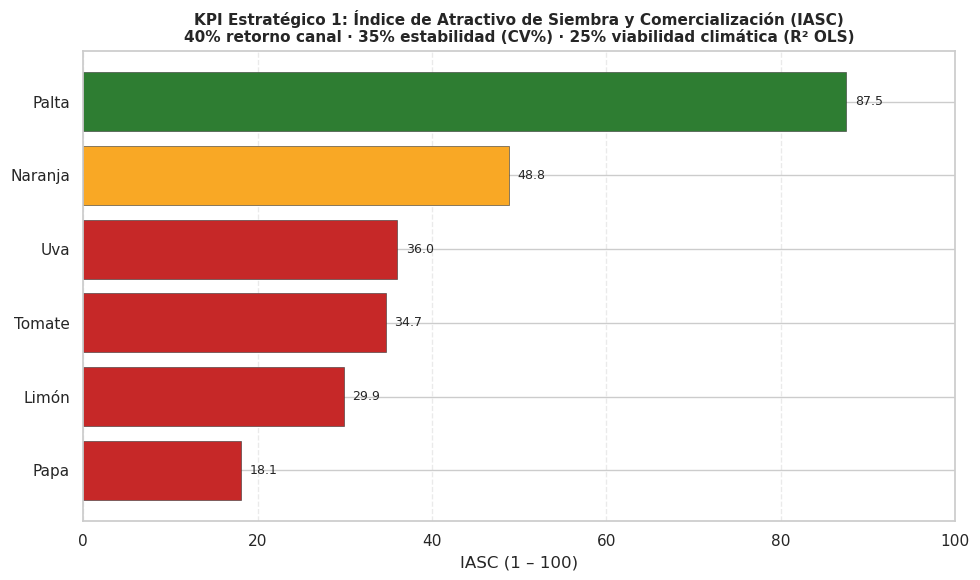


Tablero estratégico 1 — IASC (ordenado de mayor a menor atractivo):


,Producto,IASC,Semáforo,Retorno PM ($),Canal margen,CV% promedio,R² clima (test),Score retorno,Score estabilidad,Score viabilidad,Recomendación
2,Palta,87.5,Verde,"$5,095",Supermercado,25.3%,-0.635,100.0,100.0,50.0,"Palta: precio PM $5,095 en Supermercado, volat..."
1,Naranja,48.8,Amarillo,"$2,674",Supermercado,38.9%,-0.094,39.9,58.1,50.0,"Naranja: precio PM $2,674 en Supermercado, vol..."
5,Uva,36.0,Rojo,"$3,430",Supermercado,57.8%,-0.071,58.7,0.0,50.0,"Uva: precio PM $3,430 en Supermercado, volatil..."
4,Tomate,34.7,Rojo,"$1,968",Supermercado,45.5%,-0.019,22.4,37.8,50.0,"Tomate: precio PM $1,968 en Supermercado, vola..."
0,Limón,29.9,Rojo,"$1,745",Supermercado,47.9%,-0.398,16.9,30.3,50.0,"Limón: precio PM $1,745 en Supermercado, volat..."
3,Papa,18.1,Rojo,"$1,064",Supermercado,52.6%,-0.708,0.0,16.0,50.0,"Papa: precio PM $1,064 en Supermercado, volati..."


In [4]:
print("=" * 80)
print("KPI ESTRATÉGICO 1: ÍNDICE DE ATRACTIVO DE SIEMBRA Y COMERCIALIZACIÓN (IASC)")
print("=" * 80)

from sklearn.metrics import r2_score

try:
    import statsmodels.api as sm
except ImportError:
    sm = None

CANALES_IASC = ["Feria libre", "Supermercado"]
VENTANA_PM = 3
PESOS_IASC = {"retorno": 0.40, "estabilidad": 0.35, "viabilidad": 0.25}


def _normalizar(s: pd.Series, invertir: bool = False) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    valid = s.dropna()
    if valid.empty:
        return pd.Series(np.nan, index=s.index)
    lo, hi = float(valid.min()), float(valid.max())
    if hi == lo:
        out = pd.Series(50.0, index=s.index)
    else:
        out = (s - lo) / (hi - lo) * 100
    return (100 - out) if invertir else out


def _r2_test_producto(df_p: pd.DataFrame) -> float:
    if sm is None:
        return np.nan
    df_p = df_p.dropna(subset=["precio_log"] + features_climaticas).sort_values("fecha")
    if len(df_p) < 30:
        return np.nan
    split_idx = max(1, int(len(df_p) * 0.8))
    train, test = df_p.iloc[:split_idx], df_p.iloc[split_idx:]
    if test.empty:
        return np.nan
    x_train = sm.add_constant(train[features_climaticas].astype(float), has_constant="add")
    x_test = sm.add_constant(test[features_climaticas].astype(float), has_constant="add")
    ols = sm.OLS(train["precio_log"], x_train).fit()
    return float(r2_score(test["precio_log"], ols.predict(x_test)))


# --- 1) Retorno: PM del precio en el canal de mayor margen (brecha Feria–Super) ---
canal_mes = (
    df[df["lugar_monitoreo"].isin(CANALES_IASC)]
    .groupby(["producto", "anio", "mes_num", "lugar_monitoreo"])["precio"]
    .mean()
    .unstack("lugar_monitoreo")
    .reset_index()
)
for c in CANALES_IASC:
    if c not in canal_mes.columns:
        canal_mes[c] = np.nan

canal_mes["canal_margen"] = np.where(
    canal_mes["Supermercado"].fillna(-np.inf) >= canal_mes["Feria libre"].fillna(-np.inf),
    "Supermercado",
    "Feria libre",
)
canal_mes["precio_canal"] = np.where(
    canal_mes["canal_margen"] == "Supermercado",
    canal_mes["Supermercado"],
    canal_mes["Feria libre"],
)
canal_mes = canal_mes.sort_values(["producto", "anio", "mes_num"])
canal_mes["retorno_pm"] = canal_mes.groupby("producto")["precio_canal"].transform(
    lambda s: s.rolling(VENTANA_PM, min_periods=1).mean()
)
ultimo_canal = canal_mes.groupby("producto").tail(1).set_index("producto")

# --- 2) Estabilidad: inversa del CV% mensual (misma lógica que KPI Táctico 2) ---
stats_mes = (
    df.groupby(["producto", "anio", "mes_num"])["precio"]
    .agg(n="count", std="std", media="mean")
    .reset_index()
)
stats_mes = stats_mes[stats_mes["n"] >= 5]
stats_mes["cv_pct"] = (stats_mes["std"] / stats_mes["media"] * 100).replace([np.inf, -np.inf], np.nan)
cv_prod = stats_mes.groupby("producto")["cv_pct"].mean()

# --- 3) Viabilidad climática: R² test OLS (prediccion.ipynb) ---
r2_prod = {prod: _r2_test_producto(df[df["producto"] == prod]) for prod in productos_lista}

filas = []
for prod in productos_lista:
    u = ultimo_canal.loc[prod] if prod in ultimo_canal.index else None
    filas.append({
        "Producto": prod,
        "Retorno PM ($)": u["retorno_pm"] if u is not None else np.nan,
        "Canal margen": u["canal_margen"] if u is not None else "—",
        "CV% promedio": cv_prod.get(prod, np.nan),
        "R² clima (test)": r2_prod.get(prod, np.nan),
    })

df_iasc = pd.DataFrame(filas)
df_iasc["Score retorno"] = _normalizar(df_iasc.set_index("Producto")["Retorno PM ($)"]).values
df_iasc["Score estabilidad"] = _normalizar(df_iasc.set_index("Producto")["CV% promedio"], invertir=True).values
r2_clip = df_iasc["R² clima (test)"].clip(lower=0)
df_iasc["Score viabilidad"] = _normalizar(r2_clip).values

df_iasc["IASC"] = (
    PESOS_IASC["retorno"] * df_iasc["Score retorno"].fillna(0)
    + PESOS_IASC["estabilidad"] * df_iasc["Score estabilidad"].fillna(0)
    + PESOS_IASC["viabilidad"] * df_iasc["Score viabilidad"].fillna(0)
).round(1)


def _semaforo(v):
    if pd.isna(v):
        return "—"
    if v >= 70:
        return "Verde"
    if v >= 40:
        return "Amarillo"
    return "Rojo"


def _recomendacion(row):
    partes = []
    if pd.notna(row["Retorno PM ($)"]):
        partes.append(f"precio PM ${row['Retorno PM ($)']:,.0f} en {row['Canal margen']}")
    if pd.notna(row["CV% promedio"]):
        vol = "baja" if row["CV% promedio"] <= cv_prod.median() else "alta"
        partes.append(f"volatilidad {vol} (CV {row['CV% promedio']:.1f}%)")
    if pd.notna(row["R² clima (test)"]):
        clima = "alineada" if row["R² clima (test)"] >= 0.05 else "limitada"
        partes.append(f"viabilidad climática {clima} (R²={row['R² clima (test)']:.2f})")
    if row["IASC"] >= 70:
        accion = "Priorizar siembra/comercialización"
    elif row["IASC"] >= 40:
        accion = "Monitorear y ajustar canal"
    else:
        accion = "Postergar o reducir exposición"
    detalle = ", ".join(partes) if partes else "datos insuficientes"
    return f"{row['Producto']}: {detalle} → {accion}"


df_iasc["Semáforo"] = df_iasc["IASC"].map(_semaforo)
df_iasc["Recomendación"] = df_iasc.apply(_recomendacion, axis=1)
df_iasc = df_iasc.sort_values("IASC", ascending=True)

color_map = {"Verde": "#2E7D32", "Amarillo": "#F9A825", "Rojo": "#C62828", "—": "#9E9E9E"}
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    df_iasc["Producto"],
    df_iasc["IASC"],
    color=df_iasc["Semáforo"].map(color_map),
    edgecolor="#333",
    linewidth=0.4,
)
ax.set_xlabel("IASC (1 – 100)")
ax.set_title(
    "KPI Estratégico 1: Índice de Atractivo de Siembra y Comercialización (IASC)\n"
    "40% retorno canal · 35% estabilidad (CV%) · 25% viabilidad climática (R² OLS)",
    fontsize=11,
    weight="bold",
)
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4)
for bar, val in zip(bars, df_iasc["IASC"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", fontsize=9)
plt.tight_layout(pad=1.2)
plt.savefig(f"{RECURSOS_DIR}/kpi1_iasc_barras.png", dpi=150, bbox_inches="tight")
plt.show()

tablero_est1 = df_iasc[
    [
        "Producto", "IASC", "Semáforo", "Retorno PM ($)", "Canal margen",
        "CV% promedio", "R² clima (test)", "Score retorno", "Score estabilidad",
        "Score viabilidad", "Recomendación",
    ]
].sort_values("IASC", ascending=False).copy()

tablero_show = tablero_est1.copy()
tablero_show["Retorno PM ($)"] = tablero_show["Retorno PM ($)"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
)
tablero_show["CV% promedio"] = tablero_show["CV% promedio"].map(
    lambda x: f"{x:.1f}%" if pd.notna(x) else "—"
)
tablero_show["R² clima (test)"] = tablero_show["R² clima (test)"].map(
    lambda x: f"{x:.3f}" if pd.notna(x) else "—"
)
for col in ["Score retorno", "Score estabilidad", "Score viabilidad", "IASC"]:
    tablero_show[col] = tablero_show[col].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")

print("\nTablero estratégico 1 — IASC (ordenado de mayor a menor atractivo):")
display(tablero_show)

df_iasc.sort_values("IASC", ascending=False).to_csv(
    f"{RECURSOS_DIR}/tabla_iasc_productos.csv", index=False, encoding="utf-8-sig"
)


**KPI Estratégico 1 (IASC):** Índice sintético (1–100, semáforo) que ordena productos por atractivo de siembra/comercialización. Combina **retorno** (PM en canal de mayor margen), **estabilidad** (inversa del CV% mensual) y **viabilidad climática** (R² del modelo OLS). El desglose interactivo por producto vive en el tablero Streamlit (`tableros.py`).

### Interpretación ejecutiva: prioridad de productos

El IASC combina retorno, estabilidad y viabilidad climática en una escala de 0 a 100 para priorizar productos. En este análisis, la Palta presenta el puntaje más alto y semáforo verde, por lo que se recomienda priorizar inversión y recursos comerciales en dicho producto.

La Naranja exhibe un rendimiento intermedio que requiere monitoreo continuo. Uva, Tomate, Limón y Papa muestran atractivos relativos más bajos; se sugiere revisar estrategias de calidad, canales y exposición antes de asignar mayores recursos a estos productos.

En forma complementaria, la capacidad predictiva exclusiva de las variables climáticas sobre el precio es limitada (R² bajos en la evaluación). Se recomienda incorporar variables de oferta/demanda y calidad del lote para respaldar decisiones de inversión a nivel de portafolio.

KPI ESTRATÉGICO 2: BRECHA POR CANAL Y CALIDAD


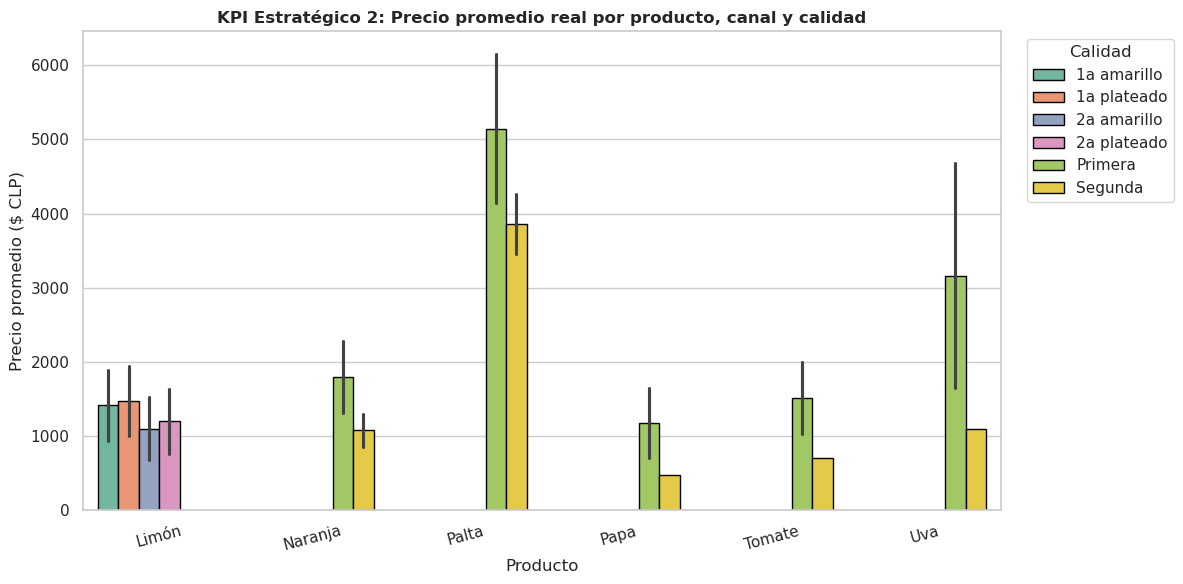


Tablero estratégico 2 (precio, canal, calidad y brecha):


,producto,calidad,precio_feria,precio_super,brecha_$,n_total
0,Limón,1a amarillo,$940,"$1,893",$953,561
1,Limón,1a plateado,"$1,007","$1,949",$942,399
2,Limón,2a amarillo,$674,"$1,525",$851,267
3,Limón,2a plateado,$759,"$1,639",$879,176
4,Naranja,Primera,"$1,308","$2,277",$970,817
5,Naranja,Segunda,$859,"$1,292",$434,337
6,Palta,Primera,"$4,141","$6,150","$2,009",651
7,Palta,Segunda,"$3,461","$4,267",$807,461
8,Papa,Primera,$702,"$1,652",$951,1120
9,Tomate,Primera,"$1,024","$2,003",$978,680


In [5]:
print("=" * 80)
print("KPI ESTRATÉGICO 2: BRECHA POR CANAL Y CALIDAD")
print("=" * 80)

if "calidad" not in df.columns:
    raise RuntimeError("Se requiere la columna 'calidad' para este KPI.")

df_canal_cal = (
    df.groupby(["producto", "lugar_monitoreo", "calidad"])["precio"]
    .agg(precio_promedio="mean", n="count")
    .reset_index()
)
df_canal_cal = df_canal_cal[df_canal_cal["n"] >= 5]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=df_canal_cal, x="producto", y="precio_promedio",
    hue="calidad", dodge=True, palette="Set2", edgecolor="black", ax=ax,
)
ax.set_title("KPI Estratégico 2: Precio promedio real por producto, canal y calidad", fontsize=12, weight="bold")
ax.set_xlabel("Producto")
ax.set_ylabel("Precio promedio ($ CLP)")
ax.legend(title="Calidad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Brecha super - feria por producto y calidad
brechas = []
for (prod, cal), sub in df_canal_cal.groupby(["producto", "calidad"]):
    canales = sub.set_index("lugar_monitoreo")["precio_promedio"]
    if {"Supermercado", "Feria libre"}.issubset(canales.index):
        brechas.append({
            "producto": prod, "calidad": cal,
            "precio_feria": canales["Feria libre"],
            "precio_super": canales["Supermercado"],
            "brecha_$": canales["Supermercado"] - canales["Feria libre"],
            "n_total": sub["n"].sum(),
        })

tabla_est2 = pd.DataFrame(brechas).sort_values(["producto", "calidad"]) if brechas else df_canal_cal.copy()
print("\nTablero estratégico 2 (precio, canal, calidad y brecha):")
if brechas:
    tabla_est2_show = tabla_est2.copy()
    for col in ["precio_feria", "precio_super", "brecha_$"]:
        tabla_est2_show[col] = tabla_est2_show[col].map(lambda x: f"${x:,.0f}")
    display(tabla_est2_show)
else:
    display(df_canal_cal.round({"precio_promedio": 0}))


**KPI Estratégico 2:** Cruza la dimensión **cualitativa (calidad)** con precio promedio real y brecha Supermercado–Feria, según el documento de indicadores.

### Interpretación ejecutiva: elección de canal de venta

El análisis de brechas confirma que, en promedio, el Supermercado remunera por encima de la Feria libre. La magnitud de la brecha varía por producto y calidad; por ejemplo, la Uva Primera presenta la brecha relativa más alta, aunque con volumen reducido en ese canal.

La Palta Primera combina una brecha favorable y volumen elevado, constituyéndose en el mejor candidato para priorizar ingreso al canal supermercadista. Para la Papa, el mayor volumen no necesariamente se traduce en mayor ingreso absoluto por unidad, por lo que la decisión debe considerar costos logísticos y margen absoluto.

En términos generales, elevar la calidad del producto tiene un impacto positivo en el precio en ambos canales y constituye una palanca operativa relevante antes de cambiar de estrategia de canal.

# Tablero Táctico · Category Managers

**Horizonte:** semanal / mensual

1. **KPI 1:** Amplitud de mercado semanal (precio máximo − mínimo por semana).
2. **KPI 2:** Estabilidad mensual (CV%) + brecha Feria–Supermercado.


KPI TÁCTICO 1: AMPLITUD DE MERCADO SEMANAL
Mes de referencia (gráfico): Marzo 2025


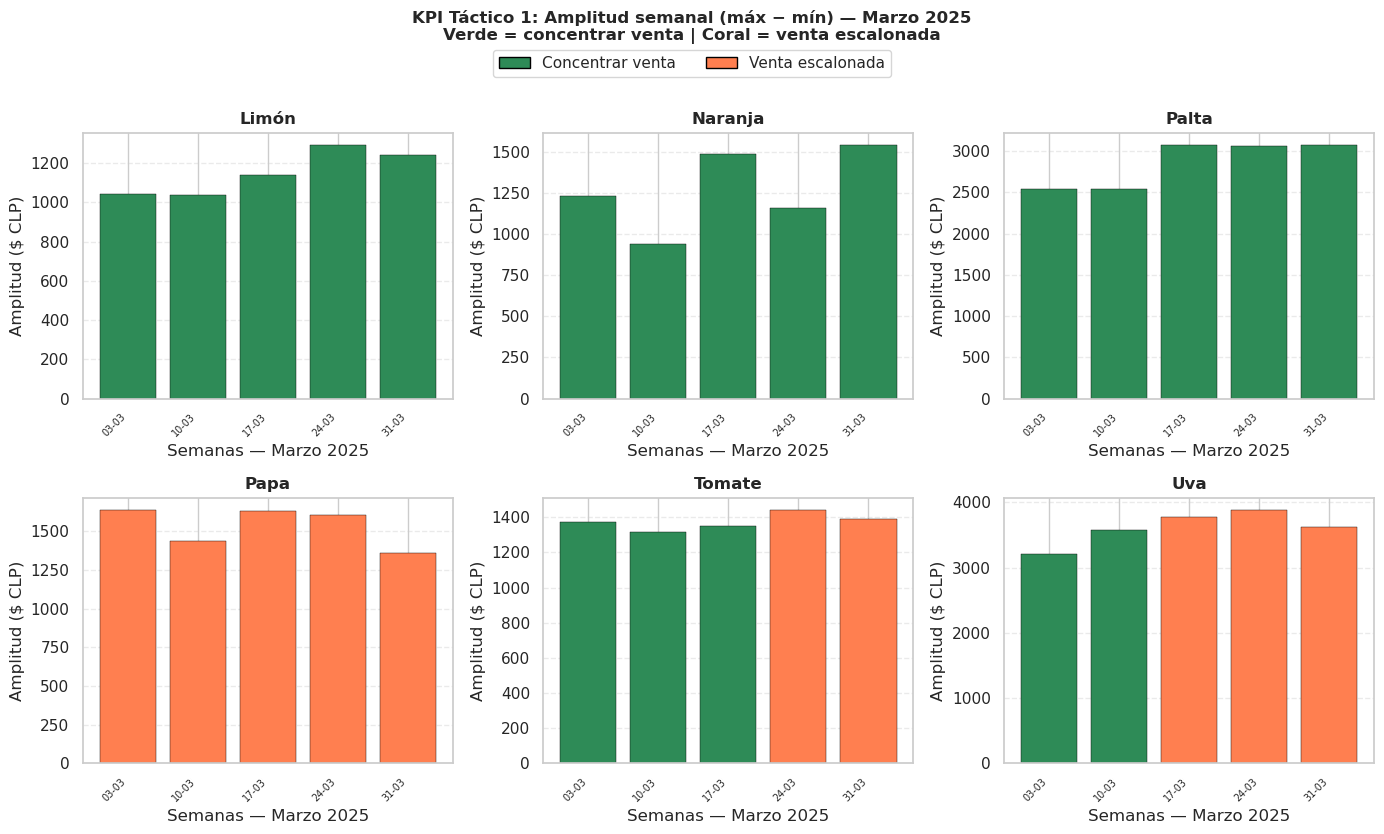


Tablero táctico 1:


,producto,semana,mes_nombre,anio,amplitud,recomendacion
0,Limón,2,Enero,2024,"$1,090",Concentrar venta
1,Limón,3,Enero,2024,"$1,140",Concentrar venta
2,Limón,4,Enero,2024,"$1,040",Concentrar venta
3,Limón,5,Enero,2024,$997,Concentrar venta
4,Limón,6,Febrero,2024,$946,Concentrar venta
5,Limón,7,Febrero,2024,$990,Concentrar venta
6,Limón,8,Febrero,2024,$830,Concentrar venta
7,Limón,9,Febrero,2024,"$1,057",Concentrar venta
8,Limón,10,Marzo,2024,$933,Concentrar venta
9,Limón,11,Marzo,2024,$890,Concentrar venta


In [6]:
print("=" * 80)
print("KPI TÁCTICO 1: AMPLITUD DE MERCADO SEMANAL")
print("=" * 80)

if "df" not in globals() or not isinstance(globals().get("df"), pd.DataFrame):
    if "df_raw" not in globals():
        raise RuntimeError("Ejecuta Paso 1 y Paso 2 antes de este KPI.")
    df, productos_lista, features_climaticas, _, _, _ = preparar_df_analisis(df_raw, globals().get("n_inicial"))
elif "productos_lista" not in globals():
    productos_lista = sorted(df["producto"].unique().tolist())

df_amp = df.copy()
df_amp["semana_inicio"] = df_amp["fecha"] - pd.to_timedelta(df_amp["fecha"].dt.dayofweek, unit="D")

tabla_amp = (
    df_amp.groupby(["producto", "anio", "mes_num", "semana", "semana_inicio"])["precio"]
    .agg(precio_max="max", precio_min="min", n="count")
    .reset_index()
)
tabla_amp["amplitud"] = (tabla_amp["precio_max"] - tabla_amp["precio_min"]).round(0)
tabla_amp = tabla_amp[tabla_amp["n"] >= 3].copy()

mediana_amp = tabla_amp.groupby("producto")["amplitud"].transform("median")
tabla_amp["recomendacion"] = np.where(
    tabla_amp["amplitud"] >= mediana_amp,
    "Venta escalonada",
    "Concentrar venta",
)

ANIO_REF, MES_REF, MES_REF_NOMBRE = mes_referencia(tabla_amp, productos=productos_lista)
print(f"Mes de referencia (gráfico): {MES_REF_NOMBRE} {ANIO_REF}")

tabla_amp_graf = tabla_amp[(tabla_amp["anio"] == ANIO_REF) & (tabla_amp["mes_num"] == MES_REF)].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
for ax, prod in zip(axes.flatten(), productos_lista):
    sub = tabla_amp_graf[tabla_amp_graf["producto"] == prod].sort_values("semana_inicio")
    if sub.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(prod, weight="bold")
        continue
    colors = np.where(sub["recomendacion"] == "Venta escalonada", "coral", "seagreen")
    etiquetas = sub["semana_inicio"].dt.strftime("%d-%m")
    ax.bar(range(len(sub)), sub["amplitud"], color=colors, edgecolor="black", linewidth=0.3)
    ax.set_title(prod, weight="bold")
    ax.set_ylabel("Amplitud ($ CLP)")
    ax.set_xlabel(f"Semanas — {MES_REF_NOMBRE} {ANIO_REF}")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=7)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    f"KPI Táctico 1: Amplitud semanal (máx − mín) — {MES_REF_NOMBRE} {ANIO_REF}\n"
    "Verde = concentrar venta | Coral = venta escalonada",
    fontsize=12,
    weight="bold",
    y=1.04,
)
from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(facecolor="seagreen", edgecolor="black", label="Concentrar venta"),
        Patch(facecolor="coral", edgecolor="black", label="Venta escalonada"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=True,
)
plt.tight_layout()
plt.show()

tablero_tact1 = tabla_amp[["producto", "semana", "mes_num", "anio", "amplitud", "recomendacion"]].sort_values(["producto", "anio", "semana"])
tablero_tact1_show = tablero_tact1.copy()
tablero_tact1_show["mes_nombre"] = tablero_tact1_show["mes_num"].map(MESES_ES)
tablero_tact1_show = tablero_tact1_show.drop(columns=["mes_num"])
tablero_tact1_show["amplitud"] = tablero_tact1_show["amplitud"].map(lambda x: f"${x:,.0f}")
tablero_tact1_show = tablero_tact1_show[["producto", "semana", "mes_nombre", "anio", "amplitud", "recomendacion"]]
print("\nTablero táctico 1:")
display(tablero_tact1_show.head(30))


**KPI Táctico 1:** Amplitud alta → mercado dinámico (venta escalonada). Amplitud baja → precios predecibles (concentrar venta).

### Interpretación operativa: estrategia de venta semanal

La amplitud semanal (máximo − mínimo) sintetiza la volatilidad de precio en una semana. Semanas con amplitud elevada recomiendan escalonar la venta para mitigar riesgo de precios adversos; semanas con amplitud reducida permiten concentrar la venta en el momento de mayor precio.

En este análisis, la Palta muestra amplitudes significativas, por lo que escalonar la venta puede aumentar el ingreso. El Tomate presenta baja variabilidad intra‑semanal, por lo que concentrar la venta en momentos favorables es apropiado. El Limón requiere seguimiento semanal debido a su comportamiento variable.

KPI TÁCTICO 2: ESTABILIDAD MENSUAL (CV%) + BRECHA FERIA–SUPERMERCADO


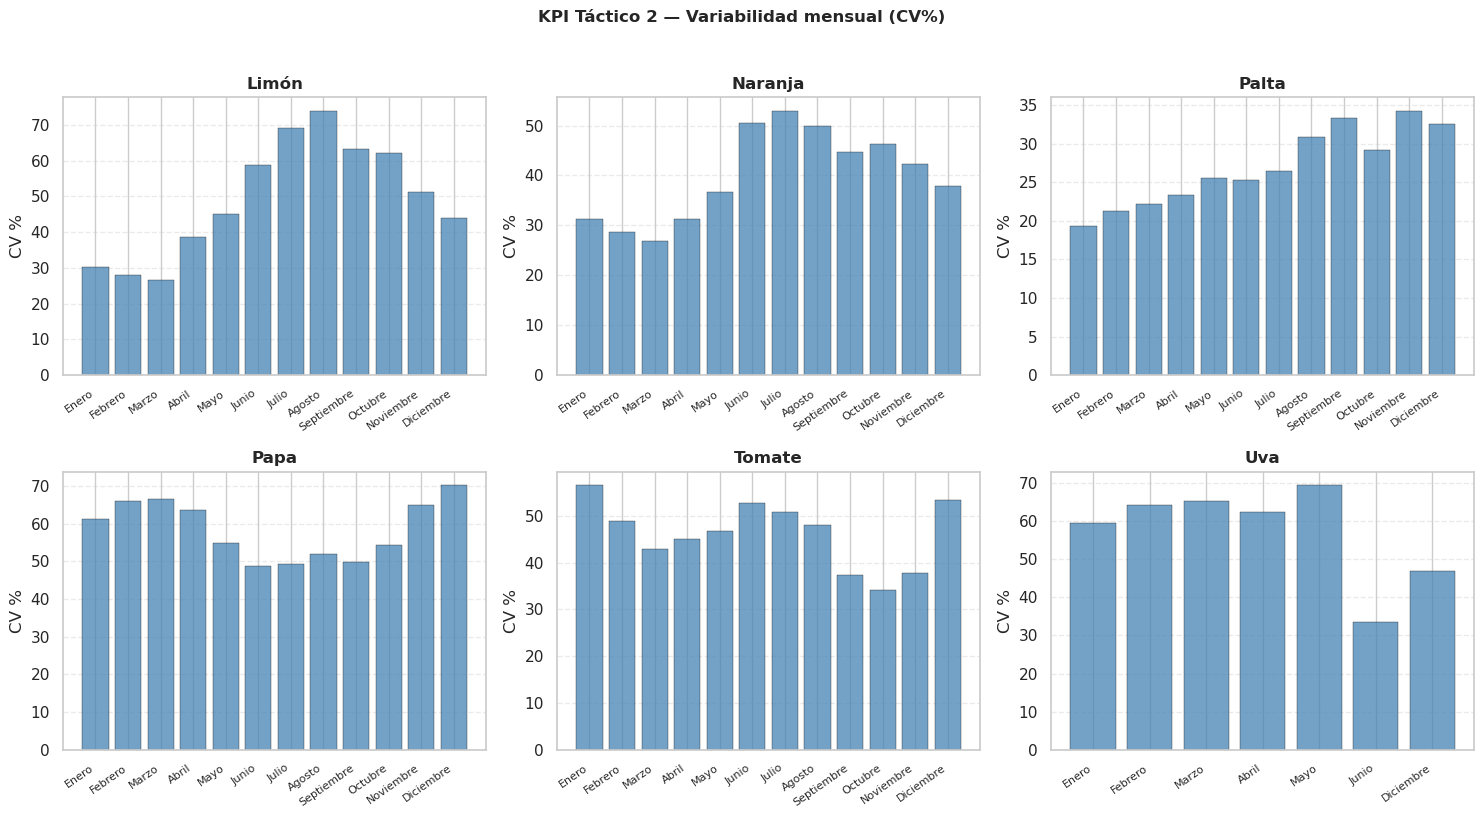

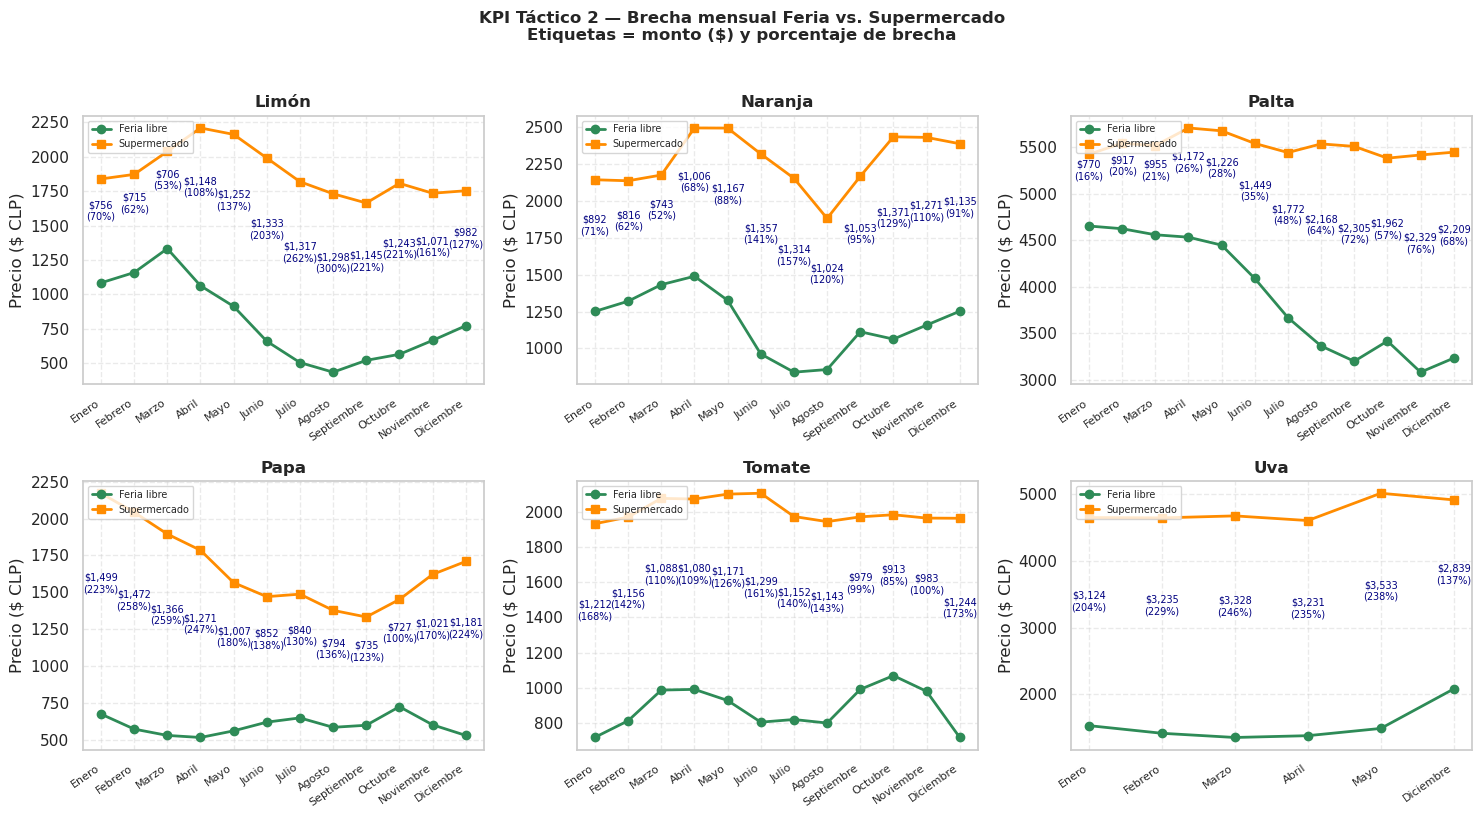


Tablero táctico 2:


,producto,mes_nombre,n,cv_pct,precio_feria,precio_super,brecha_canal,brecha_pct,zona_decision
0,Limón,Enero,130,30.2%,"$1,083","$1,839",$756,69.8%,Estable + contrato viable
1,Limón,Febrero,135,28.0%,"$1,158","$1,872",$715,61.8%,Estable + contrato viable
2,Limón,Marzo,143,26.5%,"$1,332","$2,039",$706,53.0%,Estable + contrato viable
3,Limón,Abril,136,38.6%,"$1,062","$2,210","$1,148",108.1%,Estable + contrato viable
4,Limón,Mayo,123,45.2%,$912,"$2,163","$1,252",137.3%,Estable + priorizar supermercado
...,...,...,...,...,...,...,...,...,...
62,Uva,Marzo,90,65.3%,"$1,350","$4,678","$3,328",246.5%,Volátil + priorizar supermercado
63,Uva,Abril,58,62.3%,"$1,377","$4,608","$3,231",234.7%,Volátil + priorizar supermercado
64,Uva,Mayo,10,69.5%,"$1,486","$5,018","$3,533",237.8%,Volátil + priorizar supermercado
65,Uva,Junio,10,33.6%,"$1,850",—,—,—,Estable + contrato viable


In [7]:
print("=" * 80)
print("KPI TÁCTICO 2: ESTABILIDAD MENSUAL (CV%) + BRECHA FERIA–SUPERMERCADO")
print("=" * 80)

if "df" not in globals() or not isinstance(globals().get("df"), pd.DataFrame):
    if "df_raw" not in globals():
        raise RuntimeError("Ejecuta Paso 1 y Paso 2 antes de este KPI.")
    df, productos_lista, features_climaticas, _, _, _ = preparar_df_analisis(df_raw, globals().get("n_inicial"))
elif "productos_lista" not in globals():
    productos_lista = sorted(df["producto"].unique().tolist())

CANALES = ["Feria libre", "Supermercado"]
MIN_N_MES = 5

stats_mes = (
    df.groupby(["producto", "mes_num", "mes_nombre"])["precio"]
    .agg(n="count", precio_medio="mean", std="std")
    .reset_index()
)
stats_mes["cv_pct"] = (stats_mes["std"] / stats_mes["precio_medio"] * 100).round(1)

canal_mes = (
    df[df["lugar_monitoreo"].isin(CANALES)]
    .groupby(["producto", "mes_num", "lugar_monitoreo"])["precio"].mean()
    .unstack("lugar_monitoreo").reset_index()
)
for c in CANALES:
    if c not in canal_mes.columns:
        canal_mes[c] = np.nan
canal_mes["precio_feria"] = canal_mes["Feria libre"].round(0)
canal_mes["precio_super"] = canal_mes["Supermercado"].round(0)
canal_mes["brecha_canal"] = (canal_mes["Supermercado"] - canal_mes["Feria libre"]).round(0)
canal_mes["brecha_pct"] = np.where(
    canal_mes["Feria libre"] > 0,
    (canal_mes["brecha_canal"] / canal_mes["Feria libre"] * 100).round(1),
    np.nan,
)

kpi_t2 = stats_mes.merge(
    canal_mes[["producto", "mes_num", "precio_feria", "precio_super", "brecha_canal", "brecha_pct"]],
    on=["producto", "mes_num"],
    how="left",
)
kpi_t2 = kpi_t2[kpi_t2["n"] >= MIN_N_MES].sort_values(["producto", "mes_num"])

cv_med = kpi_t2["cv_pct"].median()
brecha_med = kpi_t2["brecha_canal"].abs().median()

def zona_decision(row):
    cv_alto = row["cv_pct"] >= cv_med
    brecha_alta = abs(row["brecha_canal"]) >= brecha_med if pd.notna(row["brecha_canal"]) else False
    if cv_alto and brecha_alta:
        return "Volátil + priorizar supermercado"
    if cv_alto:
        return "Volátil + venta flexible"
    if brecha_alta:
        return "Estable + priorizar supermercado"
    return "Estable + contrato viable"

kpi_t2["zona_decision"] = kpi_t2.apply(zona_decision, axis=1)

# --- Gráfico 1: variabilidad (CV%) ---
fig_cv, axes_cv = plt.subplots(2, 3, figsize=(15, 8))
for ax, prod in zip(axes_cv.flatten(), productos_lista):
    sub = kpi_t2[kpi_t2["producto"] == prod]
    if sub.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(prod, weight="bold")
        continue
    x = np.arange(len(sub))
    ax.bar(x, sub["cv_pct"], color="steelblue", alpha=0.75, edgecolor="black", linewidth=0.3)
    ax.set_ylabel("CV %")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["mes_nombre"], rotation=35, ha="right", fontsize=8)
    ax.set_title(prod, weight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

fig_cv.suptitle("KPI Táctico 2 — Variabilidad mensual (CV%)", fontsize=12, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Gráfico 2: brecha por canal (dos líneas + monto y % de brecha) ---
fig_br, axes_br = plt.subplots(2, 3, figsize=(15, 8))
for ax, prod in zip(axes_br.flatten(), productos_lista):
    sub = kpi_t2[kpi_t2["producto"] == prod].dropna(subset=["precio_feria", "precio_super"])
    if sub.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(prod, weight="bold")
        continue
    x = np.arange(len(sub))
    ax.plot(x, sub["precio_feria"], color="seagreen", marker="o", linewidth=2, label="Feria libre")
    ax.plot(x, sub["precio_super"], color="darkorange", marker="s", linewidth=2, label="Supermercado")
    for i, row in enumerate(sub.itertuples()):
        if pd.notna(row.brecha_canal):
            y_mid = (row.precio_feria + row.precio_super) / 2
            ax.annotate(
                f"${row.brecha_canal:,.0f}\n({row.brecha_pct:.0f}%)",
                (i, y_mid),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=7,
                color="navy",
            )
    ax.set_ylabel("Precio ($ CLP)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["mes_nombre"], rotation=35, ha="right", fontsize=8)
    ax.set_title(prod, weight="bold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.4)

fig_br.suptitle(
    "KPI Táctico 2 — Brecha mensual Feria vs. Supermercado\n"
    "Etiquetas = monto ($) y porcentaje de brecha",
    fontsize=12,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

tablero_tact2 = kpi_t2[
    ["producto", "mes_nombre", "n", "cv_pct", "precio_feria", "precio_super", "brecha_canal", "brecha_pct", "zona_decision"]
]
tablero_tact2_show = tablero_tact2.copy()
tablero_tact2_show["cv_pct"] = tablero_tact2_show["cv_pct"].map(lambda x: f"{x:.1f}%")
tablero_tact2_show["precio_feria"] = tablero_tact2_show["precio_feria"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
)
tablero_tact2_show["precio_super"] = tablero_tact2_show["precio_super"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
)
tablero_tact2_show["brecha_canal"] = tablero_tact2_show["brecha_canal"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "—"
)
tablero_tact2_show["brecha_pct"] = tablero_tact2_show["brecha_pct"].map(
    lambda x: f"{x:.1f}%" if pd.notna(x) else "—"
)
print("\nTablero táctico 2:")
display(tablero_tact2_show)


**KPI Táctico 2:** Combina volatilidad mensual (CV%) con brecha de canal para decidir fijación de precio y canal de venta.

### Interpretación operativa: meses recomendados para contratos

La variabilidad mensual medida por CV% indica la predictibilidad del precio. Meses con CV% bajos son adecuados para negociar contratos de precio fijo con supermercados; meses con CV% altos requieren mayor flexibilidad y venta día a día.

Productos con estacionalidad marcada (por ejemplo, Tomate) pueden ser candidatos a contratos en periodos de baja variabilidad y a venta flexible en periodos volátiles. La Uva, dado su comportamiento altamente variable y la escasez de datos, no es recomendable para compromisos de precio hasta contar con mayor evidencia.

# Tablero Operativo · Supervisores / productores

**Horizonte:** diario

1. **KPI 1:** Umbral óptimo de venta — precio del día vs. precio referencial mensual.
2. **KPI 2:** Umbral óptimo de cosecha — temperatura y humedad óptimas por producto.


KPI OPERATIVO 1: UMBRAL ÓPTIMO DE VENTA VS. PRECIO REFERENCIAL
Mes de referencia (gráfico): Marzo 2025


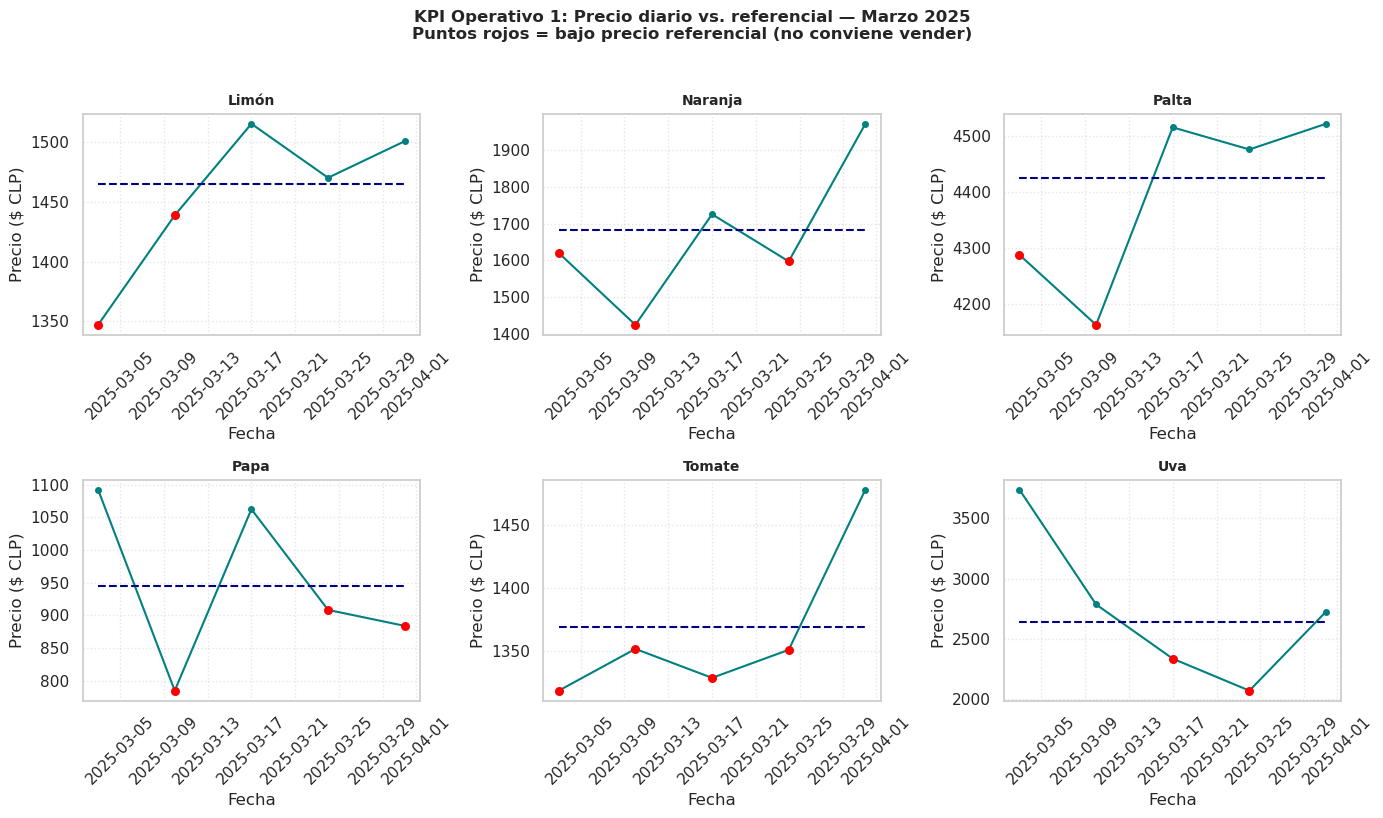


Tablero operativo 1 (muestra):


,producto,fecha,precio,precio_referencial,estado
59,Limón,2025-03-03,"$1,347","$1,465",Bajo precio referencial
60,Limón,2025-03-10,"$1,439","$1,465",Bajo precio referencial
61,Limón,2025-03-17,"$1,515","$1,465",Sobre precio referencial
62,Limón,2025-03-24,"$1,470","$1,465",Sobre precio referencial
63,Limón,2025-03-31,"$1,501","$1,465",Sobre precio referencial
161,Naranja,2025-03-03,"$1,620","$1,683",Bajo precio referencial
162,Naranja,2025-03-10,"$1,424","$1,683",Bajo precio referencial
163,Naranja,2025-03-17,"$1,725","$1,683",Sobre precio referencial
164,Naranja,2025-03-24,"$1,597","$1,683",Bajo precio referencial
165,Naranja,2025-03-31,"$1,972","$1,683",Sobre precio referencial


In [8]:
print("=" * 80)
print("KPI OPERATIVO 1: UMBRAL ÓPTIMO DE VENTA VS. PRECIO REFERENCIAL")
print("=" * 80)

ref_mes = df.groupby(["producto", "anio", "mes_num"])["precio"].mean().reset_index(name="precio_referencial")
df_venta = df.merge(ref_mes, on=["producto", "anio", "mes_num"], how="left")
df_venta["estado"] = np.where(
    df_venta["precio"] >= df_venta["precio_referencial"],
    "Sobre precio referencial",
    "Bajo precio referencial",
)

# Serie diaria por producto (promedio del día)
df_diario = (
    df_venta.groupby(["producto", "fecha", "anio", "mes_num"])
    .agg(precio=("precio", "mean"), precio_referencial=("precio_referencial", "mean"))
    .reset_index()
)
df_diario["estado"] = np.where(
    df_diario["precio"] >= df_diario["precio_referencial"],
    "Sobre precio referencial",
    "Bajo precio referencial",
)

ANIO_REF, MES_REF, MES_REF_NOMBRE = mes_referencia(df_diario, productos=productos_lista, min_registros=3)
print(f"Mes de referencia (gráfico): {MES_REF_NOMBRE} {ANIO_REF}")

df_diario_graf = df_diario[
    (df_diario["fecha"].dt.year == ANIO_REF) & (df_diario["fecha"].dt.month == MES_REF)
].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False)
for ax, prod in zip(axes.flatten(), productos_lista):
    sub = df_diario_graf[df_diario_graf["producto"] == prod].sort_values("fecha")
    if sub.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(prod, weight="bold", fontsize=10)
        continue
    ax.plot(sub["fecha"], sub["precio"], marker="o", markersize=4, label="Precio día", color="teal")
    ax.plot(sub["fecha"], sub["precio_referencial"], linestyle="--", color="navy", label="Ref. mensual")
    bajo = sub[sub["estado"] == "Bajo precio referencial"]
    if not bajo.empty:
        ax.scatter(bajo["fecha"], bajo["precio"], color="red", s=30, zorder=5, label="Bajo ref.")
    ax.set_title(prod, weight="bold", fontsize=10)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio ($ CLP)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle(
    f"KPI Operativo 1: Precio diario vs. referencial — {MES_REF_NOMBRE} {ANIO_REF}\n"
    "Puntos rojos = bajo precio referencial (no conviene vender)",
    fontsize=12,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

tablero_oper1 = df_diario_graf[["producto", "fecha", "precio", "precio_referencial", "estado"]].copy()
tablero_oper1["fecha"] = pd.to_datetime(tablero_oper1["fecha"]).dt.strftime("%Y-%m-%d")
tablero_oper1["precio"] = tablero_oper1["precio"].round(0).map(lambda x: f"${x:,.0f}")
tablero_oper1["precio_referencial"] = tablero_oper1["precio_referencial"].round(0).map(lambda x: f"${x:,.0f}")

def _color_venta(val):
    if val == "Bajo precio referencial":
        return "color: red"
    return "color: green"

print("\nTablero operativo 1 (muestra):")
display(tablero_oper1.head(40).style.applymap(_color_venta, subset=["estado"]))


**KPI Operativo 1:** Si el precio del día está **bajo** el promedio mensual de referencia, conviene postergar la venta (filas en rojo).

### Interpretación operativa: decisión diaria de venta

El gráfico compara el precio diario con el referencial mensual. Los días en que el precio diario está por debajo del referencial representan situaciones en las que conviene postergar la venta o buscar alternativas de comercialización para evitar pérdidas de margen.

Productos con pocos días por debajo del referencial (por ejemplo, Palta) muestran mayor consistencia y pueden comercializarse con menor riesgo; otros productos requieren una evaluación caso a caso antes de concretar la venta.

KPI OPERATIVO 2: UMBRAL ÓPTIMO DE COSECHA (TEMPERATURA Y HUMEDAD)
Mes de referencia (gráfico): Marzo 2025


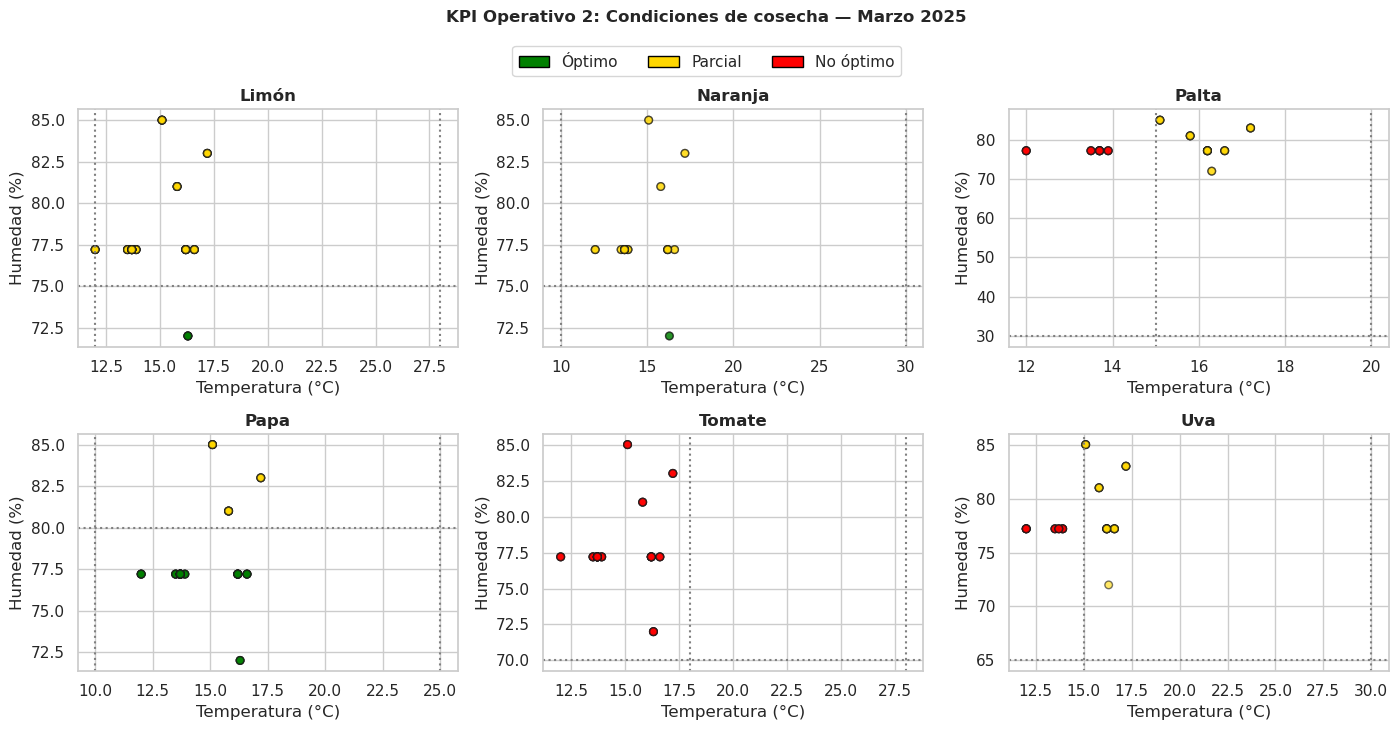


Tablero operativo 2 (muestra):


,producto,calidad,fecha,temperatura,humedad,temperatura optima,humedad optima,estado_cosecha
270,Limón,1a plateado,2025-03-03,17.2°C,83%,Si,No,Parcial
271,Limón,1a amarillo,2025-03-03,17.2°C,83%,Si,No,Parcial
272,Limón,1a plateado,2025-03-03,17.2°C,83%,Si,No,Parcial
273,Limón,2a amarillo,2025-03-03,17.2°C,83%,Si,No,Parcial
274,Limón,2a plateado,2025-03-03,17.2°C,83%,Si,No,Parcial
275,Limón,1a amarillo,2025-03-10,16.3°C,72%,Si,Si,Óptimo
276,Limón,1a plateado,2025-03-10,16.3°C,72%,Si,Si,Óptimo
277,Limón,2a amarillo,2025-03-10,16.3°C,72%,Si,Si,Óptimo
278,Limón,2a plateado,2025-03-10,16.3°C,72%,Si,Si,Óptimo
279,Limón,1a amarillo,2025-03-10,16.3°C,72%,Si,Si,Óptimo


In [9]:
print("=" * 80)
print("KPI OPERATIVO 2: UMBRAL ÓPTIMO DE COSECHA (TEMPERATURA Y HUMEDAD)")
print("=" * 80)

# Rangos orientativos (Palta según documento de indicadores; resto calibrado agronómicamente)
UMBRALES_COSECHA = {
    "Palta": {"temp_min": 15, "temp_max": 20, "hum_max": 30},
    "Limón": {"temp_min": 12, "temp_max": 28, "hum_max": 75},
    "Naranja": {"temp_min": 10, "temp_max": 30, "hum_max": 75},
    "Tomate": {"temp_min": 18, "temp_max": 28, "hum_max": 70},
    "Papa": {"temp_min": 10, "temp_max": 25, "hum_max": 80},
    "Uva": {"temp_min": 15, "temp_max": 30, "hum_max": 65},
}

def evaluar_cosecha(row):
    u = UMBRALES_COSECHA.get(row["producto"], {"temp_min": 10, "temp_max": 30, "hum_max": 80})
    ok_t = u["temp_min"] <= row["temperatura"] <= u["temp_max"]
    ok_h = row["humedad"] <= u["hum_max"]
    if ok_t and ok_h:
        return "Óptimo", "background-color: #c8e6c9"
    if ok_t or ok_h:
        return "Parcial", "background-color: #fff9c4"
    return "No óptimo", "background-color: #ffcdd2"

rows = []
for _, r in df.dropna(subset=["temperatura", "humedad"]).iterrows():
    estado, _ = evaluar_cosecha(r)
    u = UMBRALES_COSECHA.get(r["producto"], {"temp_min": 10, "temp_max": 30, "hum_max": 80})
    rows.append({
        "producto": r["producto"],
        "calidad": r["calidad"] if pd.notna(r["calidad"]) else "—",
        "fecha": r["fecha"].date() if hasattr(r["fecha"], "date") else r["fecha"],
        "temperatura": round(r["temperatura"], 1),
        "humedad": round(r["humedad"], 1),
        "temp_optima": u["temp_min"] <= r["temperatura"] <= u["temp_max"],
        "hum_optima": r["humedad"] <= u["hum_max"],
        "estado_cosecha": estado,
    })

tablero_oper2 = pd.DataFrame(rows)
tablero_oper2["fecha_dt"] = pd.to_datetime(tablero_oper2["fecha"])
tablero_oper2["anio"] = tablero_oper2["fecha_dt"].dt.year
tablero_oper2["mes_num"] = tablero_oper2["fecha_dt"].dt.month

ANIO_REF, MES_REF, MES_REF_NOMBRE = mes_referencia(tablero_oper2, productos=productos_lista, min_registros=5)
print(f"Mes de referencia (gráfico): {MES_REF_NOMBRE} {ANIO_REF}")

tablero_oper2_graf = tablero_oper2[
    (tablero_oper2["fecha_dt"].dt.year == ANIO_REF) & (tablero_oper2["fecha_dt"].dt.month == MES_REF)
].copy()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, prod in zip(axes.flatten(), productos_lista):
    sub = tablero_oper2_graf[tablero_oper2_graf["producto"] == prod].sort_values("fecha_dt")
    if sub.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(prod, weight="bold")
        continue
    u = UMBRALES_COSECHA.get(prod, {"temp_min": 10, "temp_max": 30, "hum_max": 80})
    ax.scatter(sub["temperatura"], sub["humedad"], c=sub["estado_cosecha"].map({"Óptimo": "green", "Parcial": "gold", "No óptimo": "red"}), alpha=0.6, edgecolor="k", s=30)
    ax.axvline(u["temp_min"], color="grey", linestyle=":")
    ax.axvline(u["temp_max"], color="grey", linestyle=":")
    ax.axhline(u["hum_max"], color="grey", linestyle=":")
    ax.set_title(prod, weight="bold")
    ax.set_xlabel("Temperatura (°C)")
    ax.set_ylabel("Humedad (%)")

fig.suptitle(
    f"KPI Operativo 2: Condiciones de cosecha — {MES_REF_NOMBRE} {ANIO_REF}",
    fontsize=12,
    weight="bold",
    y=1.04,
)
from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(facecolor="green", edgecolor="black", label="Óptimo"),
        Patch(facecolor="gold", edgecolor="black", label="Parcial"),
        Patch(facecolor="red", edgecolor="black", label="No óptimo"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    frameon=True,
)
plt.tight_layout()
plt.show()

def _color_fila(row):
    if row["estado_cosecha"] == "Óptimo":
        return ["background-color: #c8e6c9"] * len(row)
    if row["estado_cosecha"] == "Parcial":
        return ["background-color: #fff9c4"] * len(row)
    return ["background-color: #ffcdd2"] * len(row)

tablero_oper2_show = tablero_oper2_graf.drop(columns=["fecha_dt", "anio", "mes_num"]).copy()
tablero_oper2_show = tablero_oper2_show.rename(columns={
    "temp_optima": "temperatura optima",
    "hum_optima": "humedad optima",
})
tablero_oper2_show = tablero_oper2_show[
    ["producto", "calidad", "fecha", "temperatura", "humedad", "temperatura optima", "humedad optima", "estado_cosecha"]
]
tablero_oper2_show["temperatura"] = tablero_oper2_show["temperatura"].map(lambda t: f"{t:.1f}°C")
tablero_oper2_show["humedad"] = tablero_oper2_show["humedad"].map(lambda h: f"{int(round(h))}%")
tablero_oper2_show["temperatura optima"] = tablero_oper2_show["temperatura optima"].map({True: "Si", False: "No"})
tablero_oper2_show["humedad optima"] = tablero_oper2_show["humedad optima"].map({True: "Si", False: "No"})

print("\nTablero operativo 2 (muestra):")
display(tablero_oper2_show.head(40).style.apply(_color_fila, axis=1))


**KPI Operativo 2:** Cruza temperatura y humedad diarias con umbrales de cosecha por producto (Palta: 15–20 °C y humedad ≤ 30%, según documento).

### Interpretación operativa: condiciones de cosecha

El diagrama temperatura‑humedad clasifica cada día según condiciones óptimas para cosecha. Cuando un día se ubica en la zona no óptima, se recomienda postergar la cosecha para evitar pérdida de calidad o degradación del producto.

La Palta presenta umbrales más estrictos (15–20 °C y humedad ≤ 30%), lo que reduce la ventana operativa; la Naranja muestra mayor tolerancia y registra más días con condiciones favorables. Estas conclusiones deben integrarse con la planificación de campo y la logística de recolección.